<a href="https://colab.research.google.com/github/ChristabelEyiah/lab-3-feedforward-networks/blob/main/lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


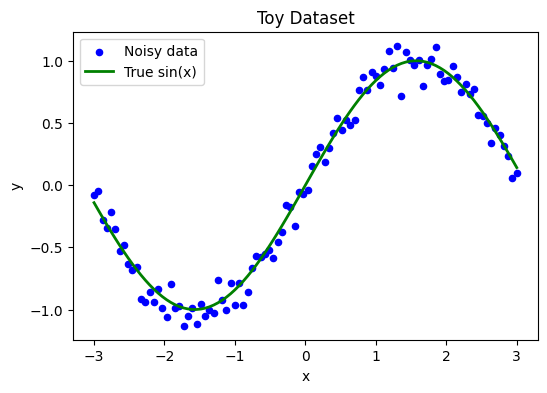

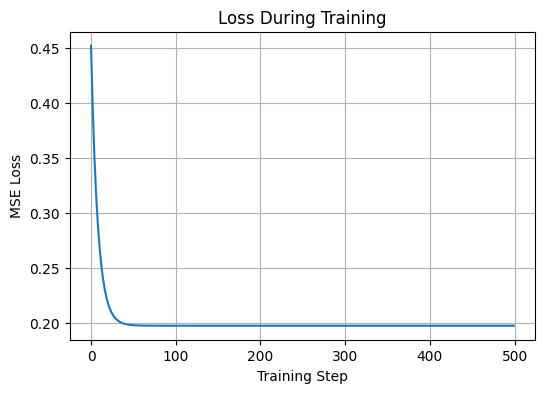

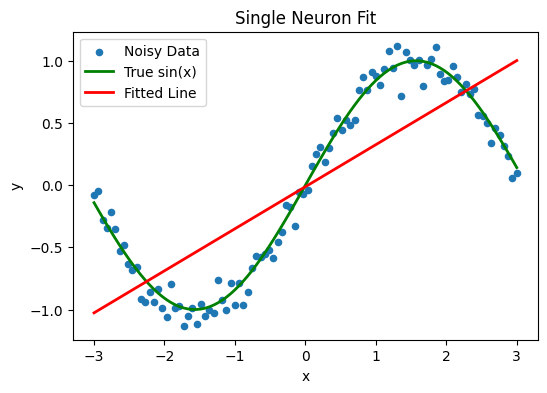

Final weight (w): 0.3380
Final bias (b): -0.0126
Final loss: 0.1974


In [18]:
# Reproducibility
np.random.seed(42)  # single seed controls both param init and data noise

# Initialising parameters
w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
learning_rate = 0.01
epochs = 500  # bumped up so the loss curve clearly plateaus
loss_history = []

# Generating the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.figure(figsize=(6,4))
plt.scatter(x, y, color="blue", s=20, label="Noisy data")
plt.plot(x, np.sin(x), color="green", linewidth=2, label="True sin(x)")
plt.title("Toy Dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

# Manual Gradient Descent (batch GD: gradients averaged over all 100 points each step)
for epoch in range(epochs):
    # Forward pass
    y_hat = w * x + b

    # Mean Squared Error Loss
    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)

    # Compute gradients (dLoss/dw, dLoss/db) — derive these by hand and compare
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Update parameters (move opposite the gradient to reduce loss)
    w -= learning_rate * dw
    b -= learning_rate * db

# Plotting the loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Loss During Training")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# Plotting fitted line
y_pred = w * x + b
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Noisy Data")
plt.plot(x, np.sin(x), color="green", linewidth=2, label="True sin(x)")
plt.plot(x, y_pred, color="red", linewidth=2, label="Fitted Line")
plt.title("Single Neuron Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Final parameters
print(f"Final weight (w): {w:.4f}")
print(f"Final bias (b): {b:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")

**Student Reasoning**
1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code?
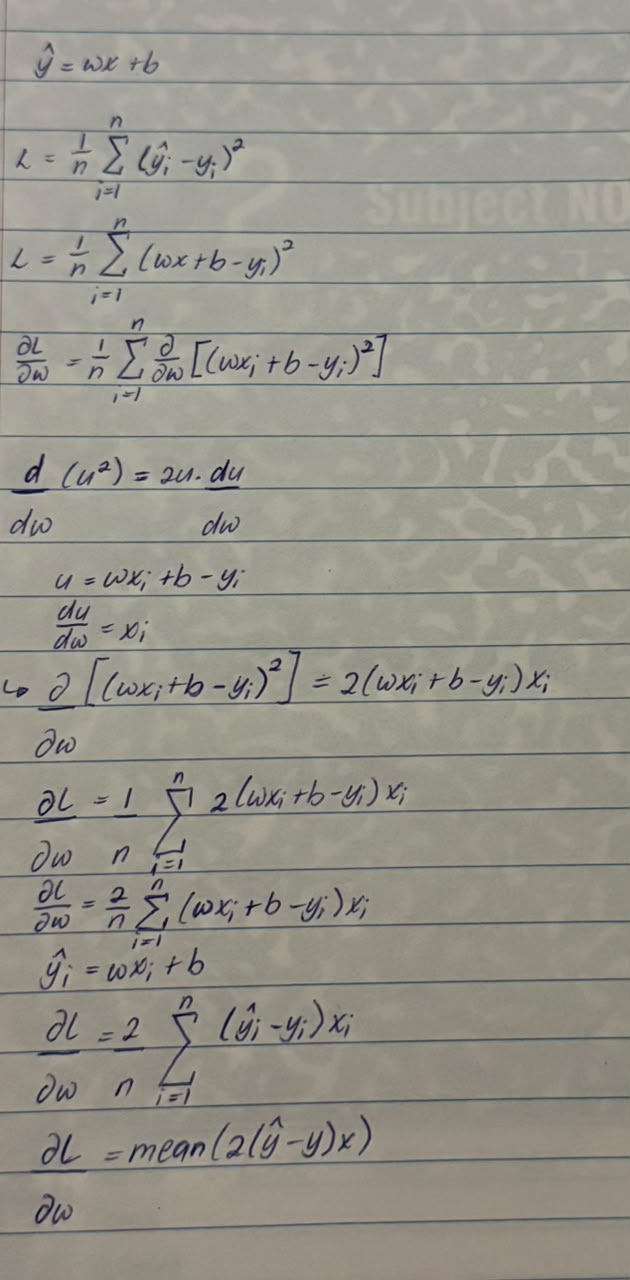


This matches the code: dw = np.mean(2 * (y_hat - y) * x)



2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?

The model is underfitting because a single neuron can only learn a straight line (y^=wx+b). A sine wave is non-linear, so increasing the number of training iterations cannot make a linear model represent it. The model lacks the capacity needed to fit the data.

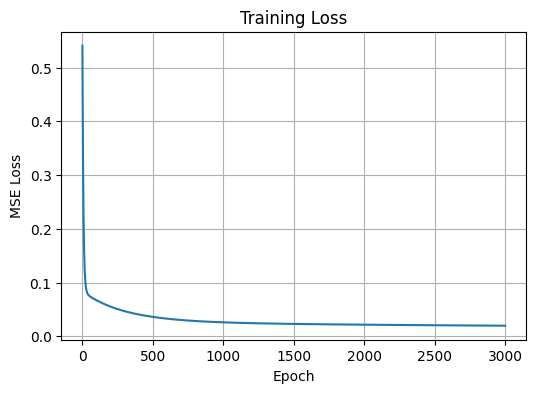

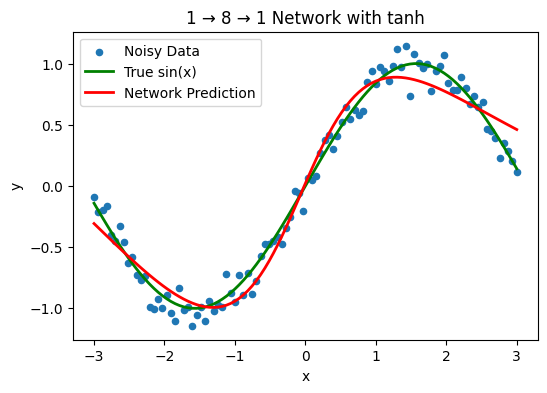

Final Loss: 0.019750


In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=(100, 1))


# Initialising parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5

W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5

lr = 0.01
epochs = 3000

loss_history = []


# Training loop
for epoch in range(epochs):


    # Forward pass
    z1 = x @ W1 + b1          # (100, 8)
    h = np.tanh(z1)           # Hidden layer activation
    y_hat = h @ W2 + b2       # (100, 1)

    loss = np.mean((y_hat - y) ** 2)
    loss_history.append(loss)


    # Backward pass
    d_yhat = 2 * (y_hat - y) / len(y)

    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)

    dh = d_yhat @ W2.T

    dz1 = dh * (1 - np.tanh(z1) ** 2)

    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    # Gradient Descent Update
    W2 -= lr * dW2
    b2 -= lr * db2

    W1 -= lr * dW1
    b1 -= lr * db1


# Plot Loss Curve
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


# Plot Final Fit
plt.figure(figsize=(6,4))
plt.scatter(x, y, s=20, label="Noisy Data")
plt.plot(x, np.sin(x), color="green", linewidth=2, label="True sin(x)")
plt.plot(x, y_hat, color="red", linewidth=2, label="Network Prediction")

plt.xlabel("x")
plt.ylabel("y")
plt.title("1 → 8 → 1 Network with tanh")
plt.legend()
plt.show()

print(f"Final Loss: {loss_history[-1]:.6f}")

**Student Reasoning**

1. Why does a stack of linear layers collapse into one linear layer?

When the tanh activation is removed, every layer in the network performs only a linear transformation. The hidden layer computes z1​=xW1​+b1, and the output layer computes y=z1​W2​+b2. Substituting the first equation into the second gives y = (xW1​+b1​)W2​+b2​=x(W1​W2​)+(b1​W2​+b2​). This can be rewritten as y = xW+b, where W = W1W2 and b = b1W2 + b2. Therefore, multiple linear layers collapse into a single linear transformation, meaning the network is mathematically equivalent to a single neuron. As a result, it can only learn straight-line relationships and cannot model the non-linear shape of a sine wave, regardless of how many linear layers are stacked.


2. What role did the hidden layer's 8 neurons play in fitting the curve?

Each hidden neuron learned a different non-linear transformation of the input: hi​=tanh(xwi​+bi​). If you plot several columns of h against x, you'll see that each neuron produces a different S-shaped curve. These curves activate over different regions of the input, allowing different neurons to respond to different parts of the sine wave. The output layer then learns weights that combine these eight non-linear features into a single prediction. By adding together multiple S-shaped functions, the network can approximate the curved shape of sin(x) much more accurately than a single straight line.


3. What is backpropagation?

Backpropagation is the algorithm that uses the chain rule to compute the gradient of the loss with respect to every weight and bias in the network, allowing gradient descent to update the parameters efficiently.





/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_795/295151984.py:34: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/tmp/ipykernel_795/295151984.py:45: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_795/295151984.py:46: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


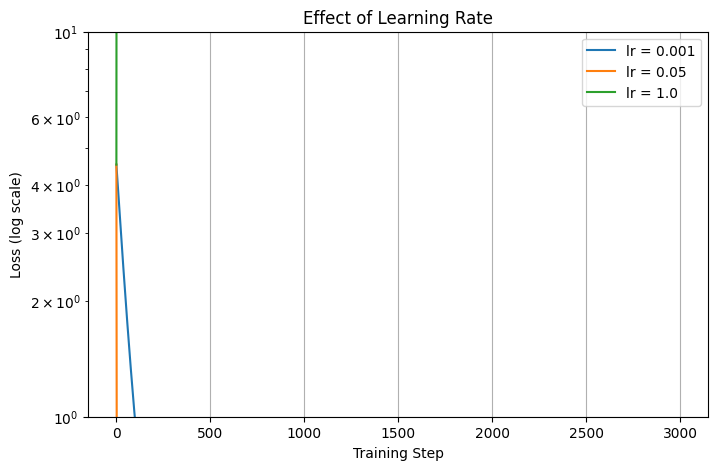

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Generating toy data
np.random.seed(42)

x = np.linspace(-3, 3, 100).reshape(-1, 1)
y = np.sin(x) + np.random.normal(0, 0.1, size=(100, 1))


# Training function
def train_toy(lr, steps=3000):

    np.random.seed(42)

    # Initialise parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []

    for step in range(steps):


        # Forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)

        y_hat = h @ W2 + b2

        loss = np.mean((y_hat - y) ** 2)
        losses.append(loss)


        # Backward pass

        d_yhat = 2 * (y_hat - y) / len(y)

        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)

        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)

        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)


        # Gradient descent

        W2 -= lr * dW2
        b2 -= lr * db2

        W1 -= lr * dW1
        b1 -= lr * db1

    return losses


# Train with different learning rates
loss_lr1 = train_toy(0.001)
loss_lr2 = train_toy(0.05)
loss_lr3 = train_toy(1.0)


# Plot comparison
plt.figure(figsize=(8,5))

plt.plot(loss_lr1, label="lr = 0.001")
plt.plot(loss_lr2, label="lr = 0.05")
plt.plot(loss_lr3, label="lr = 1.0")

plt.yscale("log")      # Log scale helps compare convergence
plt.xlabel("Training Step")
plt.ylabel("Loss (log scale)")
plt.title("Effect of Learning Rate")
plt.legend()
plt.grid(True)

plt.show()

**Student Reasoning**

The curve for learning rate = 0.001 decreases slowly because the parameter updates are very small, so the model learns steadily but takes many iterations to converge. The curve for learning rate = 0.05 drops quickly and smoothly to a low loss, indicating that the step size is appropriate and allows the model to converge efficiently. In contrast, the curve for learning rate = 1.0 is unstable, with the loss oscillating or even increasing instead of decreasing. This happens because the parameter updates are too large, causing the optimization process to overshoot the minimum of the loss function. Rather than moving closer to the optimal solution with each step, the model repeatedly jumps from one side of the minimum to the other or moves into regions with even higher loss. As a result, the model cannot settle at the minimum, causing the loss to oscillate or diverge instead of learning faster.

In [21]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

import torch
from torch.utils.data import TensorDataset, DataLoader

# Constants
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
RANDOM_STATE = 42

# Load dataset
df = pd.read_csv(OBESITY_URL)


# Encode binary categorical variables
binary_map = {
    "yes": 1,
    "no": 0,
    "Yes": 1,
    "No": 0,
    "Female": 0,
    "Male": 1
}

binary_columns = [
    "Gender",
    "family_history_with_overweight",
    "FAVC",
    "SMOKE",
    "SCC"
]

for col in binary_columns:
    df[col] = df[col].map(binary_map)


# Encode remaining categorical features
categorical_cols = [
    "CAEC",
    "CALC",
    "MTRANS"
]

for col in categorical_cols:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])


# Encode target labels
target_encoder = LabelEncoder()

df["NObeyesdad"] = target_encoder.fit_transform(df["NObeyesdad"])


# Separate features and target
X = df.drop("NObeyesdad", axis=1)
y = df["NObeyesdad"]


# Stratified 60/20/20 split

# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    stratify=y,
    random_state=RANDOM_STATE
)

# Second split: 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=RANDOM_STATE
)


# Standardise features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_val = torch.tensor(y_val.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)


# Create TensorDatasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Check shapes
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: torch.Size([1266, 16]) torch.Size([1266])
Validation: torch.Size([422, 16]) torch.Size([422])
Testing: torch.Size([423, 16]) torch.Size([423])


**Student Reasoning**

1. Why does CrossEntropyLoss need integer class labels rather than one-hot vectors in PyTorch?

CrossEntropyLoss expects the target labels to be integers because each integer represents the index of the correct class (e.g., classes 0–6). PyTorch uses these indices to directly compare the model's predicted logits with the correct class when computing the loss. Using integer labels is more efficient than one-hot encoding because it avoids storing unnecessary zeros and simplifies the loss calculation.


2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks care so much? Connect your answer to the gradient formulas you wrote in Section 1.

Neural networks are sensitive to feature scaling because their parameters are updated using gradient descent, and the gradients depend directly on the input feature values. In Section 1, the gradient for the weight was proportional to the input (x), so features with much larger values produce much larger gradients than smaller-valued features. This can cause unstable updates, slower convergence, or difficulty finding the optimal solution. Standardising the features ensures they are on a similar scale, leading to more balanced gradients and faster, more stable training. Random forests, on the other hand, split data based on feature thresholds rather than gradients, so the scale of the features has little effect on their performance.


3. What does shuffle=True on the training DataLoader do, and why does it help?

Setting shuffle=True randomly changes the order of the training samples at the beginning of every epoch. This prevents the model from learning patterns based on the order of the data and ensures that each mini-batch contains a different mix of examples. As a result, the gradient estimates are less biased, training becomes more stable, and the model is more likely to generalise well to unseen data.

In [22]:
import torch
import torch.nn as nn

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Feedforward Neural Network
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),

            nn.Linear(hidden_sizes[1], n_classes)
            # No Softmax here!
        )

    def forward(self, x):
        return self.network(x)


# Instantiate model
input_dim = X_train.shape[1]

model = FeedForwardNet(input_dim=input_dim).to(DEVICE)

# Print model architecture
print(model)


# Count trainable parameters
num_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTrainable parameters: {num_params}")


# Verify first layer manually
first_layer_params = input_dim * 64 + 64

print(f"First layer parameters (manual): {first_layer_params}")

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=7, bias=True)
  )
)

Trainable parameters: 3399
First layer parameters (manual): 1088


**Student Reasoning**

1. Show the by-hand parameter count for every layer and confirm it matches PyTorch.

The first hidden layer has 16 input features and 64 neurons, giving 16×64=1024 weights and 64 biases, for a total of 1088 parameters. The second hidden layer has 64 inputs and 32 neurons, giving 64×32=2048 weights and 32 biases, for a total of 2080 parameters. The output layer has 32 inputs and 7 output neurons, giving 32×7=224 weights and 7 biases, for a total of 231 parameters. Adding these together gives 1088 + 2080 + 231 = 3399 trainable parameters, which matches the total reported by PyTorch.

2. Why ReLU here instead of the tanh you used in Section 1? Name one advantage.

ReLU is commonly used in deep neural networks because it is computationally simple and helps gradients flow more effectively during training. Unlike tanh, which can saturate for large positive or negative inputs and produce very small gradients, ReLU does not saturate for positive values. This reduces the vanishing gradient problem and generally allows deeper networks to train faster and more efficiently.

3. What would the network compute if you removed the ReLUs?

If the ReLU activation functions were removed, every layer would perform only a linear transformation. As shown in Part 1.2, stacking multiple linear layers is mathematically equivalent to a single linear layer, so the entire network would behave like a single linear model. Consequently, it would only be able to learn linear relationships and would lose the ability to model the complex, non-linear patterns needed for tasks such as classifying the obesity dataset.

Epoch  1/50 | Train Loss: 1.8669 | Train Acc: 0.3065 | Val Loss: 1.7549 | Val Acc: 0.4905
Epoch  2/50 | Train Loss: 1.6106 | Train Acc: 0.5355 | Val Loss: 1.4216 | Val Acc: 0.6043
Epoch  3/50 | Train Loss: 1.2302 | Train Acc: 0.6295 | Val Loss: 1.0554 | Val Acc: 0.6564
Epoch  4/50 | Train Loss: 0.9390 | Train Acc: 0.6896 | Val Loss: 0.8696 | Val Acc: 0.6919
Epoch  5/50 | Train Loss: 0.7849 | Train Acc: 0.7378 | Val Loss: 0.7708 | Val Acc: 0.7370
Epoch  6/50 | Train Loss: 0.6744 | Train Acc: 0.7828 | Val Loss: 0.6979 | Val Acc: 0.7678
Epoch  7/50 | Train Loss: 0.5883 | Train Acc: 0.8096 | Val Loss: 0.6344 | Val Acc: 0.7962
Epoch  8/50 | Train Loss: 0.5153 | Train Acc: 0.8452 | Val Loss: 0.5752 | Val Acc: 0.8081
Epoch  9/50 | Train Loss: 0.4512 | Train Acc: 0.8752 | Val Loss: 0.5341 | Val Acc: 0.8270
Epoch 10/50 | Train Loss: 0.4014 | Train Acc: 0.8831 | Val Loss: 0.4920 | Val Acc: 0.8318
Epoch 11/50 | Train Loss: 0.3589 | Train Acc: 0.8965 | Val Loss: 0.4631 | Val Acc: 0.8555
Epoch 12/5

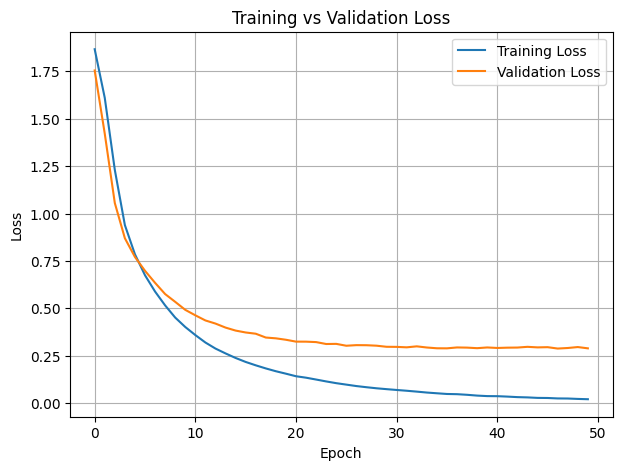

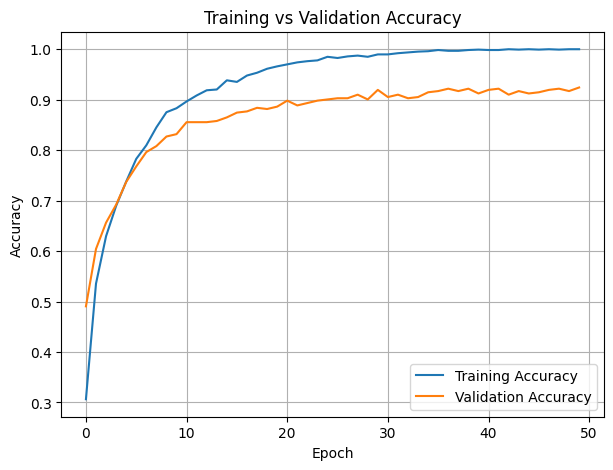


Best Validation Accuracy: 0.9242


In [23]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


# Loss function and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

num_epochs = 50

train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_val_acc = 0.0


# Training loop
for epoch in range(num_epochs):


    # Training
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        optimizer.zero_grad()

        logits = model(xb)

        loss = criterion(logits, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * xb.size(0)

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / total
    train_acc = correct / total


    # Validation
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            logits = model(xb)

            loss = criterion(logits, yb)

            val_running_loss += loss.item() * xb.size(0)

            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total

    # Save history
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            model.state_dict(),
            "ffn_best.pt"
        )

    # Print epoch summary
    print(
        f"Epoch {epoch+1:2d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

# Plot Loss Curves
plt.figure(figsize=(7,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# Plot Accuracy Curves
plt.figure(figsize=(7,5))

plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")

**Student Reasoning**

1. Map each line of the PyTorch loop to the NumPy code

i. PyTorch: outputs = model(X_batch)

   Equivalent in NumPy: y_pred = X @ W + b

   Purpose: Forward pass (computes the model's predictions from the input)



ii. PyTorch: loss = criterion(outputs, y_batch)

Equivalent in NumPy: MSE or cross entropy

Purpose: Measures how far the predictions are from the true labels


iii. PyTorch: optimizer.zero_grad()

Equivalent in NumPy: dW = 0, db = 0

Purpose: Clears gradients from the previous batch before computing new ones

iv. PyTorch: loss.backward()

Equivalent in NumPy: Compute gradients manually using derivatives

Purpose: Gradient computation (backpropagation) – calculates the gradient of the loss with respect to every parameter.


v. PyTorch: optimizer.step()

Equivalent in NumPy: W = W - learning_rate * dW and b = b - learning_rate * db

Purpose: Update rule – adjusts the model parameters using gradient descent.


2. Looking at your curves, is the model overfitting, underfitting, or well-fitted?

The model is slightly overfitting. The training loss decreases steadily from approximately 1.86 to 0.02, while the validation loss decreases from about 1.76 but levels off at around 0.30 after roughly 25 epochs. Similarly, the training accuracy increases from about 31% to 100%, whereas the validation accuracy improves from about 49% to only 92–93% before plateauing. The growing gap between the training and validation metrics shows that the model continues to improve on the training data but no longer gains similar improvements on unseen validation data.


3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?

PyTorch accumulates gradients by default, so optimizer.zero_grad() clears the gradients from the previous batch before computing the new ones. Without calling optimizer.zero_grad(), the gradients from multiple batches are added together. As a result, each parameter update is based on both the current and previous batches instead of only the current batch. This causes the gradients to become increasingly large, leading to incorrect weight updates, unstable training, slower convergence, or even failure of the model to learn properly. The code will still run without producing an error, making this a silent bug that is difficult to detect.
        

cpu


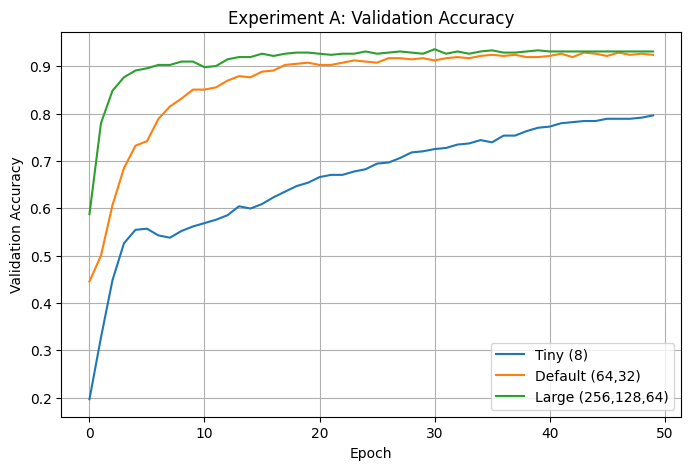

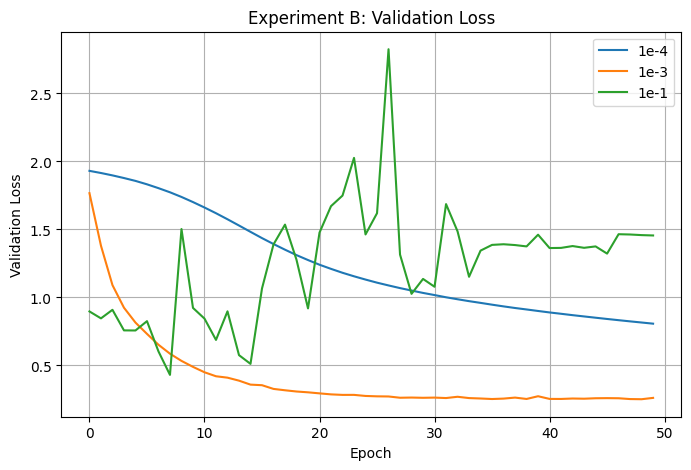

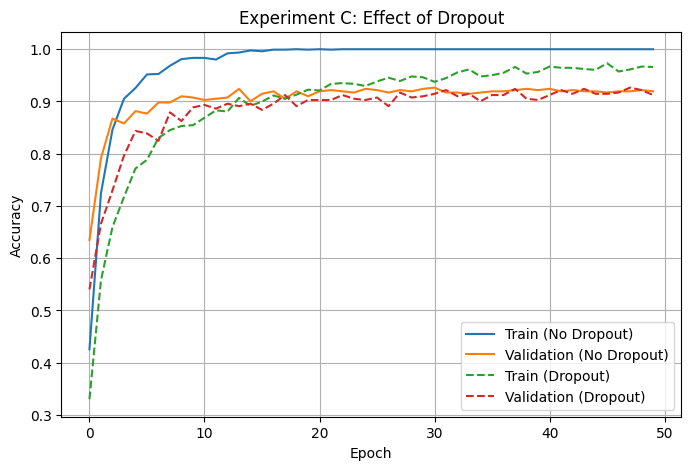

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes=(64, 32), num_classes=7, dropout=0.0):
        super().__init__()

        layers = []
        in_features = input_size

        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            in_features = h

        layers.append(nn.Linear(in_features, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_experiment(hidden_sizes=(64,32),
                   lr=1e-3,
                   batch_size=32,
                   epochs=50,
                   dropout=0.0):

    # Create model
    model = MLP(
        input_size=X_train.shape[1],
        hidden_sizes=hidden_sizes,
        num_classes=len(np.unique(y_train)),
        dropout=dropout
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    for epoch in range(epochs):

        # TRAIN
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = outputs.argmax(dim=1)

            correct += (preds == y_batch).sum().item()

            total += y_batch.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        # VALIDATION
        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                running_loss += loss.item()

                preds = outputs.argmax(dim=1)

                correct += (preds == y_batch).sum().item()

                total += y_batch.size(0)

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    return history

# experiment A
tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64,32))
large = run_experiment(hidden_sizes=(256,128,64))

plt.figure(figsize=(8,5))

plt.plot(tiny["val_acc"], label="Tiny (8)")
plt.plot(default["val_acc"], label="Default (64,32)")
plt.plot(large["val_acc"], label="Large (256,128,64)")

plt.title("Experiment A: Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()



# experiment B
lr_small = run_experiment(lr=1e-4)
lr_default = run_experiment(lr=1e-3)
lr_large = run_experiment(lr=1e-1)

plt.figure(figsize=(8,5))

plt.plot(lr_small["val_loss"], label="1e-4")
plt.plot(lr_default["val_loss"], label="1e-3")
plt.plot(lr_large["val_loss"], label="1e-1")

plt.title("Experiment B: Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()



# experiment C
no_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.0
)

dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.3
)

plt.figure(figsize=(8,5))

plt.plot(no_dropout["train_acc"], label="Train (No Dropout)")
plt.plot(no_dropout["val_acc"], label="Validation (No Dropout)")

plt.plot(dropout["train_acc"], "--", label="Train (Dropout)")
plt.plot(dropout["val_acc"], "--", label="Validation (Dropout)")

plt.title("Experiment C: Effect of Dropout")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

**Student Reasoning**

1. Capacity

Did the largest network win on validation data?

Yes. The Large (256, 128, 64) network achieved the highest validation accuracy overall, reaching around ~93–94% compared to ~92–93% for the Default network and ~80% for the Tiny network.

Where do you see diminishing returns or overfitting?

Diminishing Returns: Seen when moving from the Default model to the Large model. Increasing capacity significantly from Default to Large yields only a slight boost in accuracy, whereas the jump from Tiny to Default yielded a massive jump (~12%+ gain).

Overfitting: None of these models show overt severe overfitting (where validation accuracy drops drastically over time). However, the plateauing gap near epoch 30–50 suggests the Large network is reaching its generalization limit relative to the training set capacity.

2. Learning Rate

Do the three regimes match what you saw on the toy problem in Part 1.3?
Yes, they clearly illustrate the three classic optimization regimes:

Too Low ($10^{-4}$ / Blue line): Underflows/sluggish convergence. It learns steadily but far too slowly, remaining at a high loss after 50 epochs.

Optimal ($10^{-3}$ / Orange line): Smooth, rapid convergence toward a low validation loss without instability.

Too High ($10^{-1}$ / Green line): Severe instability and divergence/oscillation. The step sizes are too large, causing the optimization to bounce wildly around local minima and ultimately spike/fail to minimize loss.


3. Regularization
What did dropout do to the train-vs-validation gap?

Dropout significantly narrowed (shrank) the generalization gap between training accuracy and validation accuracy by suppressing perfect memorization of the training set (lowering training accuracy from ~100% down to ~96–97%, bringing it much closer to validation performance).

How dropout achieves this (Mechanism):

Dropout randomly deactivates a subset of neurons during each training forward pass, preventing units from co-adapting too strongly to specific features. This forces the network to learn redundant, robust representations rather than memorizing noise in the training set.


**Student Reasoning**

1. The Black Box, Opened
Inside loss.backward() and optimizer.step():

Gradient Computation (loss.backward()): Calculates the partial derivative of the loss with respect to every trainable weight using the chain rule (backpropagation).

Gradient Storage (loss.backward()): Traverses the computational graph backward and stores these computed derivatives directly in each parameter's .grad attribute.

Parameter Update (optimizer.step()): Adjusts the model's weights by taking a step in the opposite direction of the gradients, scaled by the learning rate (and any momentum/optimizer state).

2. Hyperparameters
If I could tune only one hyperparameter, I would pick the learning rate. It single-handedly dictates whether optimization converges smoothly, stalls out entirely (if too small), or explodes and diverges (if too large).

3. Overfitting
Biggest Gap: The largest train-vs-validation gap occurred with the large network without dropout (in Experiment C, where training accuracy hit 100% while validation accuracy plateaued lower around ~93%).

Most Effective Intervention: Applying dropout was the most effective intervention; by preventing feature co-adaptation, it lowered training performance closer to reality and significantly narrowed the generalization gap.

4. Looking Ahead
Why MLPs Struggle with Images: A standard MLP flattens images into 1D vectors, treating every pixel as independent and completely discarding spatial structure. This leads to an explosion of parameters and a failure to recognize patterns if they shift position slightly.

Key Property Needed: A better architecture (like a Convolutional Neural Network) needs spatial locality (processing nearby pixels together) and translation invariance (recognizing the same feature regardless of where it appears in the image).